In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = yf.download(
    "INFY.NS",
    period="60d",     # ✅ valid for 5m
    interval="5m"
)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df = df.dropna()

df.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Datetime,,,,,
2026-01-16 03:45:00+00:00,1663.000000,1671.000000,1653.900024,1663.500000,0
2026-01-16 03:50:00+00:00,1671.599976,1673.300049,1660.300049,1662.800049,952476
2026-01-16 03:55:00+00:00,1677.599976,1678.000000,1671.000000,1671.800049,939726
2026-01-16 04:00:00+00:00,1679.300049,1681.699951,1674.800049,1677.800049,832783
2026-01-16 04:05:00+00:00,1674.199951,1680.400024,1673.300049,1679.400024,452308


In [4]:
# EMA
df["ema_20"] = df["Close"].ewm(span=20).mean()

# RSI
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["rsi"] = 100 - (100 / (1 + rs))

# MACD
df["ema_12"] = df["Close"].ewm(span=12).mean()
df["ema_26"] = df["Close"].ewm(span=26).mean()
df["macd"] = df["ema_12"] - df["ema_26"]

In [5]:
df["return"] = df["Close"].pct_change()

# Better target (ignore noise)
df["target"] = (df["return"].shift(-1) > 0.002).astype(int)

# Extra features
df["volume_change"] = df["Volume"].pct_change()
df["price_change"] = df["Close"].pct_change()

# Lag features
df["rsi_lag1"] = df["rsi"].shift(1)
df["macd_lag1"] = df["macd"].shift(1)

# Clean data
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

In [6]:
df["target"].value_counts()

target
0    4022
1     331
Name: count, dtype: int64

In [7]:
features = [
    "rsi", "macd", "ema_20",
    "volume_change", "price_change",
    "rsi_lag1", "macd_lag1"
]

X = df[features]
y = df["target"]

In [8]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [20]:
df["target"] = (df["return"].shift(-3) > 0.004).astype(int)

In [23]:
from collections import Counter

counter = Counter(y_train)

number_of_0 = counter[0]   # SELL
number_of_1 = counter[1]   # BUY

scale = number_of_0 / number_of_1

print("Class Distribution:", counter)
print("Scale:", scale)

Class Distribution: Counter({0: 3223, 1: 259})
Scale: 12.444015444015443


In [24]:
from xgboost import XGBClassifier
scale = (number_of_0 / number_of_1)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale
)

model.fit(X_train, y_train)

# Prediction with probability
probs = model.predict_proba(X_test)[:, 1]

preds = []

for p in probs:
    if p > 0.6:
        preds.append(1)
    elif p < 0.4:
        preds.append(0)
    else:
        preds.append(0)  # HOLD as SELL for now

In [25]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8610792192881745
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       799
           1       0.14      0.14      0.14        72

    accuracy                           0.86       871
   macro avg       0.53      0.53      0.53       871
weighted avg       0.86      0.86      0.86       871



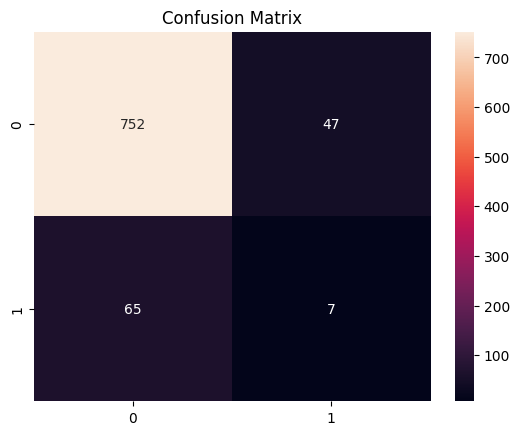

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

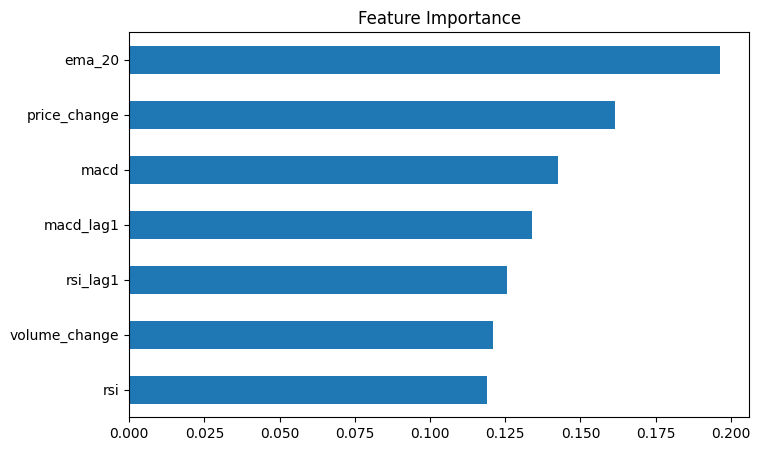

In [12]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [13]:
latest = X_test.iloc[-1:]
pred = model.predict(latest)[0]

print("Prediction:", "BUY" if pred == 1 else "SELL")

Prediction: SELL
